# Импорт нужных библиотек

In [19]:
import pandas as pd # Работа с табличными данными
import numpy as np # Вычисления с массивами
import matplotlib.pyplot # Создание статических графиков
import plotly # Создание графиков
import matplotlib.pyplot as plt # Создание графиков
import plotly.graph_objs as go # Создание графиков
from sklearn.cluster import KMeans # Алгоритм кластеризации
from sklearn.decomposition import PCA # Снижение размерности
from sklearn.metrics import silhouette_score # Оценка качества
from dash import Dash, html, dcc, callback, Output, Input  # Создание веб-дашбордов
import plotly.express as px # Интерактивные графики
import sqlite3 # Работа с БД
import dash_leaflet as dl # Визуализация маршрутов

# Создание Агента

In [53]:
class ClassificationAgent:
    """
    Класс для анализа и визуализации данных.
    
    Parameters:
        sql_path(str): Путь к .db файлу
    """
    def __init__(self, sql_path):
        """
        Инициализация экземпляра агента и загрузка данных.
        
        Parameters:
            sql_path(str): Путь к .db файлу
        """
        
        try:
            con = sqlite3.connect(sql_path)
            self.point_table = pd.read_sql("SELECT * FROM Clear_data", con=con)
        except Exception as e:
            print(f"Ошибка в загрузке из базы данных: {e}")
        try:
            self.point_table = self.point_table.drop(["Unnamed: 0", "index"], axis=1)
        except Exception as e:
            ...
            
    def __convertColumnToNumeric(self) -> pd.DataFrame:
        """
        Приводит данные в датасете к пригодным для обработки моделями.
        """

        point_data = self.point_table
        if "place_type" in self.point_table.columns:
            point_data["place_type"] = point_data["place_type"].replace({"water": 0, "forest": 1, "buildings": 2})
        if "country" in self.point_table.columns:
            point_data = point_data.drop("country", axis=1)
        point_data["time"] = pd.to_datetime(point_data["time"]).astype("int64")
        return point_data
        
    def classify_critical_areas(self):
        """
        Классификация участков по критериям опасности
        """
        indexes = self.point_table.index.tolist()
        results = []
        
        for i in range(len(indexes)):
            row = self.point_table.loc[i]
            fire = flood = evacuation = dangerous = 0
            
            # Первый критерий
            if row["forest_feature"] > 3 and row["temperature"] > 20:
                fire = 1
            elif row["forest_feature"] > 5:
                fire = 1
            
            # Второй критерий
            if row["water_feature"] > 3 and row["elevation"] < 400:
                flood = 1
            elif row["water_feature"] > 10:
                flood = 1
            
            # Третий критерий
            if row["buildings_feature"] < 150:
                evacuation = 1

            if fire == 0 and flood == 0 and evacuation == 0:
                dangerous = 0 # Безопасные зоны
            elif fire == 0 and flood == 0 and evacuation == 1:
                dangerous = 1 # Зоны со сложностью эвакуации
            elif (fire == 0 and flood == 1 and evacuation == 0) or (fire == 0 and flood == 1 and evacuation == 1):
                dangerous = 3 # Зоны с опасностью затопления и сложности эвакуации
            elif (fire == 1 and flood == 0 and evacuation == 0) or (fire == 1 and flood == 0 and evacuation == 1):
                dangerous = 3 # Зоны с пожароопасностью и сложности эвакуации
            elif (fire == 1 and flood == 1 and evacuation == 0) or (fire == 1 and flood == 1 and evacuation == 1):
                dangerous = 4 # Зоны с пожароопасностью
            
        
            results.append({
            "fire": fire,
            "flood": flood,
            "evacuation": evacuation,
            "dangerous": dangerous
            })
        
        result_df = pd.DataFrame(results)
        self.point_table = pd.concat([self.point_table, result_df], axis=1)
        return self.point_table
    def clusterization(self, clasters, table_writing):
        """
        Кластеризация GPS-точек методом K-средних с визуализацией и запись их в таблицу, если table_writing = True.

        Args:
            clasters (int): количество кластеров, на которые нужно поделить признаки
            table_writing (bool): выбор записывать кластеры втаблицу или нет
        """
        
        # Преобразуем не числовые данные
        data = self.__convertColumnToNumeric()
        
        # Снижение размерности методом PCA
        pca = PCA(n_components=2)
        
        # Удаление нечисловых столбцов перед применением PCA
        data_2d = pca.fit_transform(data)
        
        # Кластеризация методом K-средних
        kmeans = KMeans(n_clusters=clasters)
        
        # Обучение модели на исходных данных (не на PCA-проекции)
        # Это обеспечивает кластеризацию в полном признаковом пространстве
        kmeans.fit(data)
        
        # Предсказание меток кластеров для всех точек
        labels_km = kmeans.fit_predict(data)
        
        # Визуализация результатов кластеризации
        plt.scatter(
        data_2d[:, 0], # Первая главная компонента (ось X)
        data_2d[:, 1], # Вторая главная компонента (ось Y)
        c=labels_km, # Цвет точек определяется номером кластера
        cmap='viridis' # Цветовая схема (от фиолетового к желтому)
        )
        
        # Подписи осей
        plt.xlabel('x')
        plt.ylabel('y')
        
        # Отображение графика
        plt.show()
        
        # Опциональное сохранение меток в таблицу
        if table_writing:
            # Проверка наличия столбца cluster_2
            if "cluster_2" not in data.columns:
                # Если столбца нет - добавляем новый
                labels = pd.Series(labels_km)
                labels.name = "cluster_2"
                self.point_table = pd.concat([self.point_table, labels], axis=1)
            else:
                # Если столбец уже существует - удаляем старый и добавляем новый
                # Это позволяет переобучать кластеризацию с другими параметрами
                self.point_table = self.point_table.drop("cluster_2", axis=1)
                labels = pd.Series(labels_km)
                labels.name = "cluster_2"
                self.point_table = pd.concat([self.point_table, labels], axis=1)
        # Использование метрики silhouette, для оценки качества кластеризации
        print(f"Коэффициент качества кластеризации по метрике silhouette: {silhouette_score(data, kmeans.predict(data))}")
    def db_save(self):
        """
        Сохранение готовой "чистой" таблицы в базу данных.
        """
        
        con = sqlite3.connect('clear_data.db')
        try:
            # Благодаря if_exists='replace' мы исключаем любые повторы в базе данных
            self.point_table.to_sql(con=con, name="Clear_data", if_exists='replace')
            return "Успешно!"
        except Exception as e:
            return f"Ошибка в сохранении в базу данных: {e}"

# Использование Агента

## Инициализация объекта класса ClassificationAgent

In [54]:
a = ClassificationAgent(r"C:\Users\demoexam\Cross_sections_modules\Number_1\clear_data.db")

## Проведение повторной кластеризации и оценка ее качества

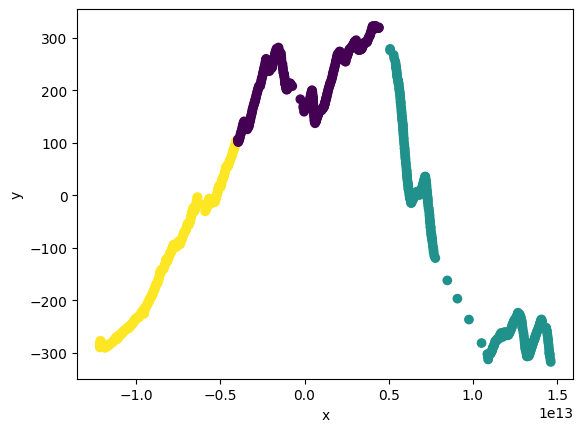

Коэффициент качества кластеризации по метрике silhouette: 0.5851650592463089


In [55]:
a.clusterization(3, True)

## Проведение полуавтоматической разметки данных

In [56]:
a.classify_critical_areas()

,track_id,point_id,time,latitude,longitude,elevation,steps,temperature,water_feature,forest_feature,buildings_feature,place_type,country,cluster,cluster_2,fire,flood,evacuation,dangerous
0,1,1,2012-09-12 21:13:13+00:00,51.505713,104.139225,501.46,3.0,-21.887001,1,3,94,2,Россия,2,2,0,0,1,1
1,1,2,2012-09-12 21:13:19+00:00,51.505694,104.139221,505.79,0.0,-21.887001,1,3,94,2,Россия,2,2,0,0,1,1
2,1,3,2012-09-12 21:13:20+00:00,51.505693,104.139224,505.79,5.0,-21.887001,1,3,94,2,Россия,2,2,0,0,1,1
3,1,4,2012-09-12 21:13:30+00:00,51.505724,104.139204,511.56,1.0,-21.887001,1,3,94,2,Россия,2,2,0,0,1,1
4,1,5,2012-09-12 21:13:37+00:00,51.505717,104.139202,514.92,1.0,-21.887001,1,3,94,2,Россия,2,2,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,1,996,2012-09-13 04:38:26+00:00,51.436646,104.007937,1957.86,10.0,-27.913502,0,0,0,0,Россия,1,1,0,0,1,1
996,1,997,2012-09-13 04:38:32+00:00,51.436709,104.007957,1957.86,17.0,-27.900501,1,0,0,0,Россия,1,1,0,0,1,1
997,1,998,2012-09-13 04:38:45+00:00,51.436813,104.007959,1954.02,29.0,-27.900501,1,0,0,0,Россия,1,1,0,0,1,1
998,1,999,2012-09-13 04:39:18+00:00,51.436993,104.007940,1950.17,23.0,-27.900501,1,0,0,0,Россия,1,1,0,0,1,1


### В итоге был выбран метод полуавтоматической разметки, так как кластеризация по методу K-means разделяет данные по их числовому различию, а не логическому, который как раз таки и нужен. Цель четко разделить с помощью алгоритма участки на опасные зоны, что и было сделано.

## Сохранение датасета в базу данных

In [57]:
a.db_save()

'Успешно!'

# Создание дашборда

In [52]:
# Загрузка базы данных
try:
    con = sqlite3.connect(r"C:\Users\demoexam\Cross_sections_modules\Number_1\clear_data.db")
    df = pd.read_sql("SELECT * FROM Clear_data", con=con)
except Exception as e:
    print(f"Ошибка в загрузке базы данных: {e}")

# Создание графика со связью высоты маршрута частотой шагов
fig = go.Figure()
fig.add_trace(go.Scatter(x=df["point_id"], y=df["elevation"], name="elevation"))
fig.add_trace(go.Scatter(x=df["point_id"], y=df["steps"], name="steps"))

def get_route():
    """
    Возвращает все маршруты в базе данных.
    """

    tracks = []
    numbers_tracks = df["track_id"].unique()
    for number in numbers_tracks:
        tracks.append(f"Маршрут №{number}")
    return tracks

# Создание экземпляра класса Dash()
app = Dash()
# Структура дашборда
app.layout = [
html.H1(children='Аналитический дашборд', style={'textAlign': 'center'}),
html.H2(children='Средняя частота шагов по сезонам', style={'textAlign': 'center'}),
dcc.Dropdown(["Зима", "Весна", "Лето", "Осень"], id="season_selector"),
html.Div(id='season_output'),
html.H2(children='Зависимость температуры от времени суток', style={'textAlign': 'center'}),
dcc.Dropdown(["Утро", "День", "Вечер", "Ночь"], id="time_selector"),
dcc.Graph(id="time_temp_graph"),
html.H2(children="Зависимость высоты и частоты шагов"),
dcc.Graph(id="ele_steps_graph", figure=fig),
html.H2(children='Визуализация маршрутов', style={'textAlign': 'center'}),
dcc.Dropdown(options=get_route() ,id="route_selector"),
dcc.Graph(id="route_map")
]

@callback(Output("season_output", "children"), Input("season_selector", "value"))
def analyze_season(selected_season):
    """
    Анализ данных по выбранному сезону.

    :arg:
        Selected_season (str): Название выбранного сезона
    """

    # Взятие из датасета нужного сезона, выбранного пользователем
    df_datetime = pd.to_datetime(df["time"])
    if selected_season == "Зима":
        filtered_data = df[df_datetime.dt.month.isin([12, 1, 2])]
    elif selected_season == "Весна":
        filtered_data = df[df_datetime.dt.month.isin([3, 4, 5])]
    elif selected_season == "Лето":
        filtered_data = df[df_datetime.dt.month.isin([6, 7, 8])]
    elif selected_season == "Осень":
        filtered_data = df[df_datetime.dt.month.isin([9, 10, 11])]
    # Возвращение среднего значения шагов за этот сезон
    return f"Средние значения: {filtered_data['steps'].mean():.2f}"

@callback(Output("time_temp_graph", "figure"), Input("time_selector", "value"))
def analyze_time_period(selected_period):
    """
    Анализ данных по времени суток.

    :arg:
        selected_period (str): Выбранное время суток
    """

    # Взятие из датасета нужного времени суток, выбранного пользователем
    df_datetime = pd.to_datetime(df["time"])
    if selected_period == "Утро":
        hours = [6, 7, 8, 9, 10, 11, 12]
    elif selected_period == "День":
        hours = [13, 14, 15, 16]
    elif selected_period == "Вечер":
        hours = [17, 18, 19, 20, 21, 22, 23, 24]
    elif selected_period == "Ночь":
        hours = [1, 2, 3, 4, 5]
    filtered_data = df[df_datetime.dt.hour.isin(hours)]
    filtered_data["hour"] = pd.to_datetime(filtered_data["time"]).dt.hour
    # Сортировка для удобства температуры относительно времени
    hourly_stats = filtered_data.groupby('hour')['temperature'].mean().reset_index()
    # Возвращение графика с зависимостью температуры от времени суток
    return px.line(hourly_stats, x="hour", y="temperature", title=f"Температура - {selected_period}")

@callback(Output("route_map", "figure"), Input("route_selector", "value"))
def track_visualization(track):
    """
    Визуализация маршрутов на интерактивной карте.
    :arg:
        track (str): Выбранный маршрут

    """

    # Инициализация словаря с точками и их названиями (порядковыми номерами)
    points = {"name": [], "latitude": [], "longitude": []}

    # Получение маршрута из датасета
    track = int(track.split("№")[1])
    track_data = df[df["track_id"] == track]

    # Взятие всех точек из маршрута в словарь points
    for i in range(len(track_data.index.tolist())):
        row = track_data.iloc[i]
        points["name"].append(f"point №{i}")
        points["latitude"].append(row["latitude"])
        points["longitude"].append(row["longitude"])

    # Создание карты с маршрутом
    fig = px.line_map(
    points,
    lat='latitude',
    lon='longitude',
    color_discrete_sequence=['red'],
    zoom=10,
    height=600,
    title='Визуализация маршрута',
    text="name"
    )
    return fig